In [ ]:
# import pandas as pd

In [ ]:
# from src.data_management.loaders import ReadRawStepLoader, MergeRawStepLoader, ProductSplitStepLoader, UnderlyingStepLoader

In [ ]:
# options_trade_underlying_ibex_db = UnderlyingStepLoader.load()

2026-02-26 22:52:05,865 | INFO | src.data_management.builders.underlying_step_builders | OptionsTradeUnderlyingIbexDatabase (with shape (406690, 15)) saved in: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\data\underlying_data\OPTIONS_TRADE_UNDERLYING_IBEX_DATABASE.csv.


In [ ]:
# # Estadísticas de la nueva columna
# print("\nEstadísticas de DaysToMaturity:")
# print(options_trade_underlying_ibex_db['DaysToMaturity'].describe())
# print(f"\nValores únicos: {options_trade_underlying_ibex_db['DaysToMaturity'].nunique()}")
# print(f"\nRango: {options_trade_underlying_ibex_db['DaysToMaturity'].min()} a {options_trade_underlying_ibex_db['DaysToMaturity'].max()} días")


Estadísticas de DaysToMaturity:
count    406690.000000
mean         52.446574
std          75.920136
min           0.000000
25%          11.000000
50%          28.000000
75%          53.000000
max        1750.000000
Name: DaysToMaturity, dtype: float64

Valores únicos: 586

Rango: 0 a 1750 días


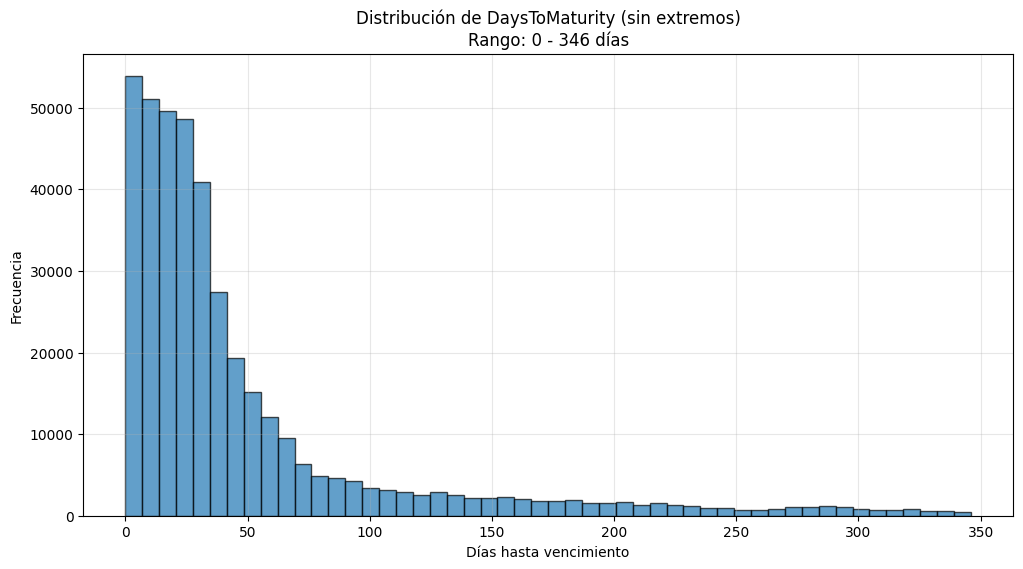

Datos originales: 406690
Datos filtrados: 402695
Rango (1%-99%): 0 - 346 días


In [ ]:
# import matplotlib.pyplot as plt

# # Calcular percentiles para eliminar valores extremos
# p1 = options_trade_underlying_ibex_db["DaysToMaturity"].quantile(0.01)
# p99 = options_trade_underlying_ibex_db["DaysToMaturity"].quantile(0.99)

# # Filtrar datos dentro del rango del 1% al 99%
# filtered_data = options_trade_underlying_ibex_db["DaysToMaturity"][(
#     options_trade_underlying_ibex_db["DaysToMaturity"] >= p1) & (
#     options_trade_underlying_ibex_db["DaysToMaturity"] <= p99)]

# # Crear histograma mejorado
# plt.figure(figsize=(12, 6))
# plt.hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
# plt.xlabel('Días hasta vencimiento')
# plt.ylabel('Frecuencia')
# plt.title(f'Distribución de DaysToMaturity (sin extremos)\nRango: {filtered_data.min():.0f} - {filtered_data.max():.0f} días')
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"Datos originales: {len(options_trade_underlying_ibex_db)}")
# print(f"Datos filtrados: {len(filtered_data)}")
# print(f"Rango (1%-99%): {p1:.0f} - {p99:.0f} días")

In [ ]:
# # Crear tabla de frecuencias
# # Definir bins para los rangos de días
# bins = [0, 10, 20, 30, 50, 100, 200, 400, 2000]
# labels = ['0-10', '10-20', '20-30', '30-50', '50-100', '100-200', '200-400', '400+']

# # Crear categorías
# options_trade_underlying_ibex_db['DaysToMaturity_Range'] = pd.cut(
#     options_trade_underlying_ibex_db['DaysToMaturity'], 
#     bins=bins, 
#     labels=labels,
#     right=False
# )

# # Crear tabla de frecuencias
# freq_table = options_trade_underlying_ibex_db['DaysToMaturity_Range'].value_counts().sort_index()
# freq_table_df = pd.DataFrame({
#     'Rango (días)': freq_table.index,
#     'Frecuencia': freq_table.values,
#     'Porcentaje (%)': (freq_table.values / len(options_trade_underlying_ibex_db) * 100).round(2),
#     'Frecuencia Acumulada': freq_table.cumsum().values,
#     'Porcentaje Acumulado (%)': (freq_table.cumsum().values / len(options_trade_underlying_ibex_db) * 100).round(2)
# })

# print("Tabla de Frecuencias - DaysToMaturity:")
# print("=" * 100)
# print(freq_table_df.to_string(index=False))
# print("=" * 100)
# print(f"Total de registros: {len(options_trade_underlying_ibex_db)}")

Tabla de Frecuencias - DaysToMaturity:
Rango (días)  Frecuencia  Porcentaje (%)  Frecuencia Acumulada  Porcentaje Acumulado (%)
        0-10       85540           21.03                 85540                     21.03
       10-20       68973           16.96                154513                     37.99
       20-30       68483           16.84                222996                     54.83
       30-50       70960           17.45                293956                     72.28
      50-100       55238           13.58                349194                     85.86
     100-200       32785            8.06                381979                     93.92
     200-400       23001            5.66                404980                     99.58
        400+        1710            0.42                406690                    100.00
Total de registros: 406690


------

In [ ]:
# RISK FREE RISK RATES
# Read .csv of risk free rates
# eonia_df = pd.read_csv("data/risk_free_rate_data/ECB Data Portal_EONIA_20260227163623.csv")
# str_df = pd.read_csv("data/risk_free_rate_data/ECB Data Portal_STR_20260227163606.csv")
# euribor3m_df = pd.read_csv("data/risk_free_rate_data/ECB Data Portal_EURIBOR3M_20260227163631.csv")
# euribor6m_df = pd.read_csv("data/risk_free_rate_data/ECB Data Portal_EURIBOR6M_20260227163642.csv")
# euribor12m_df = pd.read_csv("data/risk_free_rate_data/ECB Data Portal_EURIBOR12M_20260227163652.csv")

# Select specific columns and rename
# eonia_df = eonia_df.iloc[:,[0,-1]]
# eonia_df.columns = ["Date", "EoniaRate"]
# str_df = str_df.iloc[:,[0,-1]]
# str_df.columns = ["Date", "STRRate"]
# euribor3m_df = euribor3m_df.iloc[:,[0,-1]]
# euribor3m_df.columns = ["Date", "Euribor3MRate"]
# euribor6m_df = euribor6m_df.iloc[:,[0,-1]]
# euribor6m_df.columns = ["Date", "Euribor6MRate"]
# euribor12m_df = euribor12m_df.iloc[:,[0,-1]]
# euribor12m_df.columns = ["Date", "Euribor12MRate"]

# Convertir la columna Date a datetime para todos los DataFrames
# Hacer que Date sea índice
# for df in [eonia_df, str_df, euribor3m_df, euribor6m_df, euribor12m_df]:
#     df["Date"] = pd.to_datetime(df["Date"])
#     df.set_index("Date", inplace=True)

# Hacer merge usando unión de índices (outer join)
# risk_free_rates_df = eonia_df.join([str_df, euribor3m_df, euribor6m_df, euribor12m_df], how="outer")

# ---- Crear columna overnight unificada ----
# Ajustar EONIA restando 8.5 bps para hacerlo equivalente a €STR
# spread = 0.00085  # 8.5 bps en decimal

# # Definir cutoff
# cutoff = pd.Timestamp("2019-10-01")

# # Crear columna overnight vacía
# risk_free_rates_df["OvernightRate"] = pd.NA

# Antes de cutoff → usar EONIA - 8.5bps
# mask_pre = risk_free_rates_df.index < cutoff
# risk_free_rates_df.loc[mask_pre, "OvernightRate"] = risk_free_rates_df.loc[mask_pre, "EoniaRate"] - spread

# # Desde cutoff en adelante → usar STR directamente
# mask_post = risk_free_rates_df.index >= cutoff
# risk_free_rates_df.loc[mask_post, "OvernightRate"] = risk_free_rates_df.loc[mask_post, "STRRate"]

# ---- Mantener solo OvernightRate + Euribor ----
# risk_free_rates_df = risk_free_rates_df[["OvernightRate", "Euribor3MRate", "Euribor6MRate", "Euribor12MRate"]].copy()

# ---- Forward fill para convertir Euribor mensual en serie diaria ----
# Cada día del mes debe usar la tasa del último día publicado.
# Es decir, se hace un forward fill mensual hasta que salga la siguiente publicación.
# risk_free_rates_df[["Euribor3MRate", "Euribor6MRate", "Euribor12MRate"]] = risk_free_rates_df[["Euribor3MRate", "Euribor6MRate", "Euribor12MRate"]].ffill()

# Take dates with trades
# options_trade_underlying_ibex_df = pd.read_csv("data/underlying_data/OPTIONS_TRADE_UNDERLYING_IBEX_DATABASE.csv", sep=";")
# unique_dates = pd.to_datetime(options_trade_underlying_ibex_df["SessionDate"].unique())
# unique_dates = pd.Series(unique_dates).sort_values().reset_index(drop=True)

# # Reindexar usando solo las fechas de trading
# risk_free_rates_df = risk_free_rates_df.reindex(unique_dates)


C:\Users\danir\AppData\Local\Temp\ipykernel_24908\3852940894.py:57: DtypeWarning: Columns (0: TradeExecID) have mixed types. Specify dtype option on import or set low_memory=False.
  options_trade_underlying_ibex_df = pd.read_csv("data/underlying_data/OPTIONS_TRADE_UNDERLYING_IBEX_DATABASE.csv", sep=";")


In [ ]:
# import numpy as np
# from tqdm import tqdm

# # NUEVO STEP
# trades_underlying_df = pd.read_csv("data/underlying_data/OPTIONS_TRADE_UNDERLYING_IBEX_DATABASE.csv", sep=";",
#             header=0,
#             dtype="string",
#         )

############## TimeToExpiration ##############
# # Convert columns to datetime
# trades_underlying_df["ExecDatetime"] = pd.to_datetime(trades_underlying_df["ExecDatetime"], format='ISO8601')
# trades_underlying_df["MaturityDate"] = pd.to_datetime(trades_underlying_df["MaturityDate"], format="%Y-%m-%d")

# Calculate
# trades_underlying_df.loc[:,"TimeToExpiration"] = trades_underlying_df.loc[:,"MaturityDate"] - trades_underlying_df.loc[:,"ExecDatetime"]
# # Convert TimeToExpiration to days with decimals (more precise)
# trades_underlying_df["TimeToExpiration"] = trades_underlying_df["TimeToExpiration"].dt.total_seconds() / (24*3600)

############## RiskFreeRate con Interpolación Log-Linear ##############

# Convert rates to float
# for col in ["OvernightRate", "Euribor3MRate", "Euribor6MRate", "Euribor12MRate"]:
#     risk_free_rates_df[col] = risk_free_rates_df[col].astype(float)

# def rates_to_discount_factors(rates_df):
#     """
#     Convierte tasas de interés (en porcentaje) a factores de descuento.
    
#     Usa capitalización continua con convención ACT/360.
#     Fórmula: DF = exp(-r * T / 360), donde r está en % (ej: -0.35685%)
    
#     Parameters
#     ----------
#     rates_df : pd.DataFrame
#         DataFrame con columnas: OvernightRate, Euribor3MRate, Euribor6MRate, Euribor12MRate
    
#     Returns
#     -------
#     discount_factors : pd.DataFrame
#     tenores_days : np.array
#         Array con tenores [1, 90, 180, 360] días
#     """
#     tenores_days = np.array([1, 90, 180, 360])
#     discount_factors = pd.DataFrame(index=rates_df.index)
    
#     for tenor, col in zip(tenores_days, rates_df.columns):
#         # Convertir % a decimal dividiendo por 100
#         discount_factors[f'DF_{tenor}d'] = np.exp(-rates_df[col].values / 100 * tenor / 360)
    
#     return discount_factors, tenores_days

# discount_factors, tenores = rates_to_discount_factors(
#     risk_free_rates_df[["OvernightRate", "Euribor3MRate", "Euribor6MRate", "Euribor12MRate"]]
# )

# def interpolate_rates_vectorized(trades_df, discount_factors, tenores):
#     """
#     Interpola la tasa libre de riesgo usando log-linear interpolation.
    
#     Para cada operación, busca el DF en la curva de descuento para su TTE
#     usando interpolación lineal en espacio logarítmico.
    
#     Parameters
#     ----------
#     trades_df : pd.DataFrame
#         DataFrame con columnas ExecDatetime, TimeToExpiration
#     discount_factors : pd.DataFrame
#         DataFrame de factores de descuento por tenor
#     tenores : np.array
#         Array de tenores [1, 90, 180, 360]
    
#     Returns
#     -------
#     risk_free_rate : np.array
#         Array de tasas interpoladas en formato % (ej: -0.35%)
#     """
    # exec_dates = trades_df["ExecDatetime"].dt.date
    # discount_factors_copy = discount_factors.copy()
    # discount_factors_copy.index = discount_factors_copy.index.date
    # tte_days = trades_df["TimeToExpiration"].values
    
    # # Obtener factores de descuento para cada fecha de ejecución
    # dfs_values = discount_factors_copy.loc[exec_dates].values
    # ln_dfs = np.log(dfs_values)
    
    # # Interpolar en espacio log (log-linear interpolation)
    # ln_df_interp = np.empty(len(tte_days))
    # for i, tte in enumerate(tqdm(tte_days, desc="Interpolando RiskFreeRate")):
    #     ln_df_interp[i] = np.interp(tte, tenores, ln_dfs[i], 
    #                                  left=ln_dfs[i, 0], right=ln_dfs[i, -1])
    
#     # Convertir de vuelta a espacio lineal
#     df_interp = np.exp(ln_df_interp)
    
#     # Recuperar tasa desde DF: r = -ln(DF) * 360 / T * 100
#     risk_free_rate = -np.log(df_interp) * 360 / tte_days * 100
    
#     return risk_free_rate

# # Aplicar interpolación
# trades_underlying_df["RiskFreeRate"] = interpolate_rates_vectorized(
#     trades_underlying_df, 
#     discount_factors, 
#     tenores
# )

Interpolando RiskFreeRate: 100%|██████████| 406690/406690 [00:00<00:00, 569987.07it/s]


In [ ]:
# print("=" * 80)
# print("RESUMEN FINAL DEL PIPELINE - INTERPOLACIÓN DE TASAS LIBRES DE RIESGO")
# print("=" * 80)

# print("\n📊 ESTADÍSTICAS DE RISKFREERATE INTERPOLADA:")
# print(trades_underlying_df["RiskFreeRate"].describe())

# print("\n📈 DISTRIBUCIÓN POR CUARTILES:")
# print(f"Q0 (Min):  {trades_underlying_df['RiskFreeRate'].min():.4f}%")
# print(f"Q1 (25%):  {trades_underlying_df['RiskFreeRate'].quantile(0.25):.4f}%")
# print(f"Q2 (Med):  {trades_underlying_df['RiskFreeRate'].median():.4f}%")
# print(f"Q3 (75%):  {trades_underlying_df['RiskFreeRate'].quantile(0.75):.4f}%")
# print(f"Q4 (Max):  {trades_underlying_df['RiskFreeRate'].max():.4f}%")

# print("\n✅ VALIDACIÓN DEL PIPELINE:")
# print(f"✓ Operaciones totales: {len(trades_underlying_df):,}")
# print(f"✓ Tasas interpoladas exitosamente: {trades_underlying_df['RiskFreeRate'].notna().sum():,}")
# print(f"✓ Valores con NaN: {trades_underlying_df['RiskFreeRate'].isna().sum()}")
# print(f"✓ Tenores usados para interpolación: {list(tenores)}")

# print("\n💡 NOTA SOBRE VALORES NEGATIVOS:")
# print("   Las tasas negativas son correctas (período ECB 2017-2022).")
# print("   Para Black-Scholes/Black-76, use directamente estos valores.")

# print("\n🎯 PRÓXIMO PASO:")
# print("   Usar RiskFreeRate en cálculo de volatilidad implícita con Black-76")
# print("=" * 80)

RESUMEN FINAL DEL PIPELINE - INTERPOLACIÓN DE TASAS LIBRES DE RIESGO

📊 ESTADÍSTICAS DE RISKFREERATE INTERPOLADA:
count    406690.000000
mean         -1.725892
std           1.527322
min          -8.483269
25%          -2.003158
50%          -1.592848
75%          -0.897199
max           1.545320
Name: RiskFreeRate, dtype: float64

📈 DISTRIBUCIÓN POR CUARTILES:
Q0 (Min):  -8.4833%
Q1 (25%):  -2.0032%
Q2 (Med):  -1.5928%
Q3 (75%):  -0.8972%
Q4 (Max):  1.5453%

✅ VALIDACIÓN DEL PIPELINE:
✓ Operaciones totales: 406,690
✓ Tasas interpoladas exitosamente: 406,690
✓ Valores con NaN: 0
✓ Tenores usados para interpolación: [np.int64(1), np.int64(90), np.int64(180), np.int64(360)]

💡 NOTA SOBRE VALORES NEGATIVOS:
   Las tasas negativas son correctas (período ECB 2017-2022).
   Para Black-Scholes/Black-76, use directamente estos valores.

🎯 PRÓXIMO PASO:
   Usar RiskFreeRate en cálculo de volatilidad implícita con Black-76


In [17]:
# --- CÁLCULO DE VOLATILIDAD IMPLÍCITA (Black-76) ---
# Elegimos la opción profesional usando py_vollib, que es rápida y fiable.

# instalar dependencias en el kernel si no existe
try:
    import py_vollib
except ImportError:
    %pip install py_vollib
    import py_vollib

try:
    from scipy.optimize import newton
except ImportError:
    %pip install scipy
    from scipy.optimize import newton

# Import correcto para Black-76 (futuros)
from py_vollib.black.implied_volatility import implied_volatility as iv_black76

# Ejemplo sencillo con un contrato de futuro
sample_market_price = 60.0  # debe ser >= intrínseco
sample_F = 9000
sample_K = 8950
sample_r = -0.01725892  # r en decimal
sample_T = 30/360
sample_flag = 'c'

iv_sample = iv_black76(sample_market_price, sample_F, sample_K, sample_r, sample_T, sample_flag)
print(f"Volatilidad implícita de ejemplo: {iv_sample:.4%}")

# Función utilitaria para DataFrame

def compute_iv_black76(row):
    r = row['RiskFreeRate'] / 100
    T = row['TimeToExpiration'] / 360
    try:
        return iv_black76(row['OptionPrice'], row['UnderlyingFuturesPrice'], row['Strike'], r, T, row['OptionType'])
    except Exception:
        return np.nan

# Alternativa manual con scipy si prefieres:
from math import log, sqrt
from scipy.stats import norm

def black76_price(F, K, T, r, sigma, flag):
    d1 = (log(F/K) + 0.5*sigma**2 * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    if flag == 'c':
        return np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return np.exp(-r*T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


def find_iv_scipy(market_price, F, K, T, r, flag):
    func = lambda sigma: black76_price(F, K, T, r, sigma, flag) - market_price
    try:
        return newton(func, x0=0.2)
    except Exception:
        return np.nan

# Nota: la opción 'manual' se incluye sólo para referencia; py_vollib
# evita ese trabajo y es la opción recomendada


Volatilidad implícita de ejemplo: 2.7208%


In [35]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import newton
from py_vollib.black.implied_volatility import implied_volatility as iv_lib
from tqdm import tqdm

# --- FUNCIONES DE SOPORTE ---

def black76_price_manual(F, K, T, r, sigma, flag):
    """Fórmula teórica de Black-76 para opciones sobre futuros."""
    if sigma <= 0 or T <= 0: return 0.0
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if flag.lower() == 'c':
        return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def find_iv_manual(price, F, K, T, r, flag):
    """Cálculo de IV mediante Newton-Raphson (Scipy)."""
    # Función objetivo: Precio_Modelo - Precio_Mercado = 0
    func = lambda sigma: black76_price_manual(F, K, T, r, sigma, flag) - price
    try:
        # Semilla inicial 20%, tolerancia financiera estándar
        return newton(func, x0=0.2, tol=1e-6, maxiter=100)
    except:
        return np.nan

# --- PROCESAMIENTO DEL DATAFRAME ---

# 1. Asegurar tipos numéricos y extraer el Flag de la opción
df = trades_underlying_df.copy() # Trabajamos sobre tu df de trades
df['UnderlayingPrice'] = pd.to_numeric(df['UnderlayingPrice'], errors='coerce')
df['TradePriceOption'] = pd.to_numeric(df['TradePriceOption'], errors='coerce')
df['StrikePrice'] = pd.to_numeric(df['StrikePrice'], errors='coerce')
df['Flag'] = df['OptionContractCode'].str[0].str.lower() # 'c' o 'p'

# Listas para almacenar resultados (más rápido que .apply)
iv_library_list = []
iv_manual_list = []

# 2. Bucle de cálculo
for row in tqdm(df.itertuples(), total=len(df), desc="Calculando Volatilidades Implícitas"):
    # Extraer valores de la fila
    p = row.TradePriceOption
    f = row.UnderlayingPrice
    k = row.StrikePrice
    r = row.RiskFreeRate / 100  # Convertir de % a decimal
    t = row.TimeToExpiration / 365.0 # Black-76 usa base anual 365
    flag = row.Flag
    
    # Validaciones de seguridad (evitar logs de números negativos o divisiones por cero)
    if pd.isna(p) or pd.isna(f) or f <= 0 or k <= 0 or t <= 0 or p <= 0:
        iv_library_list.append(np.nan)
        iv_manual_list.append(np.nan)
        continue
    
    # Cálculo A: Librería py_vollib (Motor en C)
    try:
        iv_lib_val = iv_lib(p, f, k, r, t, flag)
    except:
        iv_lib_val = np.nan
    iv_library_list.append(iv_lib_val)
    
    # Cálculo B: Manual (Newton-Raphson)
    iv_man_val = find_iv_manual(p, f, k, t, r, flag)
    iv_manual_list.append(iv_man_val)

# 3. Asignación de nuevas columnas
df['IV_Library'] = iv_library_list
df['IV_Manual'] = iv_manual_list

# Resumen de resultados
print("\n" + "="*50)
print(f"Registros procesados: {len(df)}")
print(f"IVs calculadas (Library): {df['IV_Library'].notna().sum()}")
print(f"IVs calculadas (Manual):  {df['IV_Manual'].notna().sum()}")
print(f"Diferencia media (MAE):   {np.abs(df['IV_Library'] - df['IV_Manual']).mean():.2e}")
print("="*50)

# Mostrar muestra
print(df[['OptionContractCode', 'TimeToExpiration', 'RiskFreeRate', 'IV_Library', 'IV_Manual']].head())

Calculando Volatilidades Implícitas: 100%|██████████| 406690/406690 [02:53<00:00, 2341.92it/s]


Registros procesados: 406690
IVs calculadas (Library): 389717
IVs calculadas (Manual):  386012
Diferencia media (MAE):   2.66e-11
  OptionContractCode  TimeToExpiration  RiskFreeRate  IV_Library  IV_Manual
0       CIBX 9600F17         17.615475     -1.366908    0.178670   0.178670
1       PIBX 8200F17         17.608924     -1.366885    0.270855   0.270855
2       CIBX 9300F17         17.608241     -1.366883    0.193503   0.193503
3       PIBX 8500F17         17.604618     -1.366871    0.248101   0.248101
4       CIBX 9400F17         17.602176     -1.366862    0.188900   0.188900


In [31]:
import pandas as pd
import numpy as np
import time
from scipy.stats import norm
from scipy.optimize import newton
from math import log, sqrt

# --- 1. LIBRERÍA OPTIMIZADA (py_vollib) ---
from py_vollib.black.implied_volatility import implied_volatility as iv_lib

# --- 2. MÉTODO MANUAL (Black-76 + Newton-Raphson) ---
def black76_theoretical_price(F, K, T, r, sigma, flag):
    if sigma <= 0 or T <= 0: return 0
    d1 = (log(F/K) + 0.5 * sigma**2 * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    if flag.lower() == 'c':
        return np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return np.exp(-r*T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def find_iv_manual(market_price, F, K, T, r, flag):
    # Definimos la función objetivo: Precio_Modelo - Precio_Mercado = 0
    func = lambda sigma: black76_theoretical_price(F, K, T, r, sigma, flag) - market_price
    try:
        # Usamos Newton-Raphson con una semilla inicial del 20%
        return newton(func, x0=0.2, tol=1e-5, maxiter=50)
    except:
        return np.nan

# --- 3. PRUEBA DE COMPARACIÓN ---

# Datos de prueba (puedes cambiarlos por una fila de tu df)
F, K, T, r, flag = 9000, 8950, 30/365, -0.005, 'c'
market_price = 120.0 

start = time.time()
iv_pyvollib = iv_lib(market_price, F, K, r, T, flag)
end_lib = time.time() - start

start = time.time()
iv_custom = find_iv_manual(market_price, F, K, T, r, flag)
end_manual = time.time() - start

print(f"--- RESULTADOS ---")
print(f"IV py_vollib: {iv_pyvollib:.12f} (Tiempo: {end_lib:.6f}s)")
print(f"IV Manual:    {iv_custom:.12f} (Tiempo: {end_manual:.6f}s)")
print(f"Diferencia:   {abs(iv_pyvollib - iv_custom):.2e}")

--- RESULTADOS ---
IV py_vollib: 0.090422176398 (Tiempo: 0.000000s)
IV Manual:    0.090422177538 (Tiempo: 0.003053s)
Diferencia:   1.14e-09


Distribución de TimeToExpiration:
count    406690.000000
mean         51.888795
std          75.916533
min          -0.714727
25%          10.537328
50%          27.267860
75%          52.526193
max        1749.239907
Name: TimeToExpiration, dtype: float64

Operaciones con TTE > 360 días: 3272
Operaciones con TTE <= 360 días: 403418


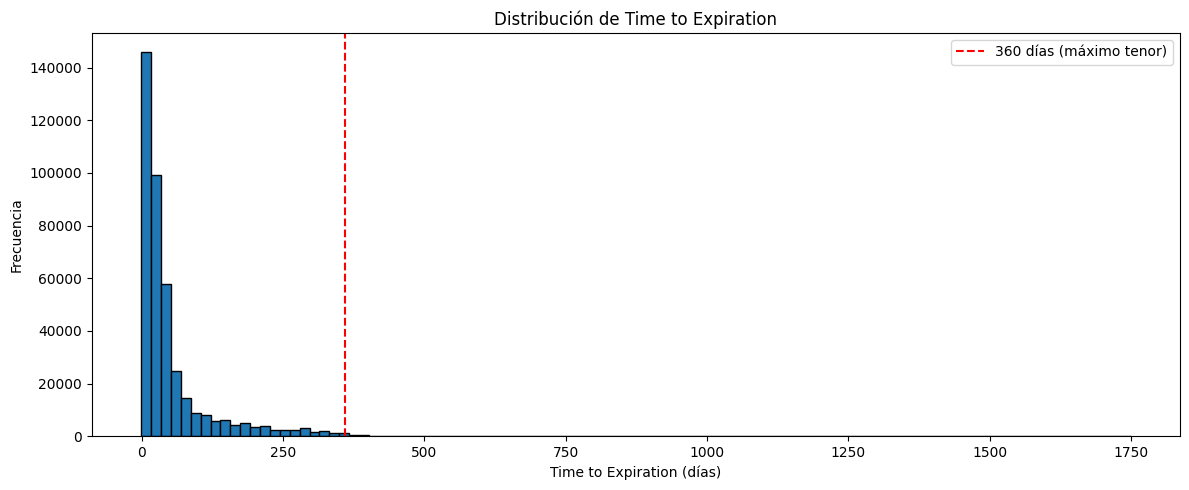

In [60]:
print("Distribución de TimeToExpiration:")
print(trades_underlying_df["TimeToExpiration"].describe())
print(f"\nOperaciones con TTE > 360 días: {(trades_underlying_df['TimeToExpiration'] > 360).sum()}")
print(f"Operaciones con TTE <= 360 días: {(trades_underlying_df['TimeToExpiration'] <= 360).sum()}")

# Histograma de TTE
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(trades_underlying_df["TimeToExpiration"], bins=100, edgecolor='black')
ax.axvline(360, color='r', linestyle='--', label='360 días (máximo tenor)')
ax.set_xlabel('Time to Expiration (días)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Time to Expiration')
ax.legend()
plt.tight_layout()
plt.show()